In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Model parameters from homework
iter_count = 10000
alpha = 1e-5  # learning rate
lambda_params = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4])
k_fold = 5
num_classes = 5
num_features = 10
ancestry_types = ['African', 'European', 'East Asian', 'Oceanian', 'Native American']

# Read the data in the CSV
data = np.loadtxt(r"C:\Users\victo\OneDrive\Documentos\DATA SCIENCE AND ANALYTICS\FULL 2024\Computational Foundations AI\TrainingData_N183_p10.csv", delimiter=',', skiprows=1, dtype=str)
X = data[:, :num_features].astype(float)
y = data[:, -1] 

# Standardize features
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
X_std = np.column_stack([np.ones(X_std.shape[0]), X_std])

# Convert ancestry labels to one-hot encoding
y_encoded = np.zeros((len(y), num_classes))
ancestry_map = {'African': 0, 'European': 1, 'EastAsian': 2, 'Oceanian': 3, 'NativeAmerican': 4}
for i, ancestry in enumerate(y):
    y_encoded[i, ancestry_map[ancestry]] = 1

In [78]:
def train_model(x, y, lambda_val):
    
    n_features = x.shape[1]
    
    # Initialize params to zero (Step 3)
    beta = np.zeros((n_features, num_classes))
    
    # Matrix for intercept terms (Step 6)
    intercept_mat = np.zeros_like(beta)
    intercept_mat[0, :] = beta[0, :]
    
    # Gradient descent (Steps 4-7)
    for _ in range(iter_count):
        # Step 4: Compute unnormalized probs
        unnorm_probs = np.exp(x @ beta)
        
        # Step 5: Compute normalized probs
        probs = unnorm_probs / np.sum(unnorm_probs, axis=1, keepdims=True)
        
        # Step 7: Update parameters
        grad = x.T @ (y - probs) - 2 * lambda_val * (beta - intercept_mat)
        beta += alpha * grad
        
    return beta

# Try training with one lambda value
lambda_test = lambda_params[0]
beta = train_model(X_std, y_encoded, lambda_test)
print("Initial training completed")

Initial training completed


In [80]:
def train_model(x, y, lambda_val):
    
    n_features = x.shape[1]
    
    # Initialize params to zero (Step 3)
    beta = np.zeros((n_features, num_classes))
    
    # Matrix for intercept terms (Step 6)
    intercept_mat = np.zeros_like(beta)
    intercept_mat[0, :] = beta[0, :]
    
    # Gradient descent (Steps 4-7)
    for _ in range(iter_count):
        # Step 4: Compute unnormalized probs
        unnorm_probs = np.exp(x @ beta)
        
        # Step 5: Compute normalized probs
        probs = unnorm_probs / np.sum(unnorm_probs, axis=1, keepdims=True)
        
        # Step 7: Update parameters
        grad = x.T @ (y - probs) - 2 * lambda_val * (beta - intercept_mat)
        beta += alpha * grad
        
    return beta

# Try training with one lambda value
lambda_test = lambda_params[0]
beta = train_model(X_std, y_encoded, lambda_test)
print("Initial training completed")

Initial training completed


In [53]:
def cross_validate(x, y, lambda_val):
    """5-fold cross validation"""
    n_samples = x.shape[0]
    fold_size = n_samples // k_fold
    indices = np.random.permutation(n_samples)
    cv_scores = []
    
    for fold in range(k_fold):
        # Split data for validation
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size if fold < k_fold - 1 else n_samples
        val_indices = indices[val_start:val_end]
        train_indices = np.concatenate([indices[:val_start], indices[val_end:]])
        
        # Train on fold
        fold_x = x[train_indices]
        fold_y = y[train_indices]
        beta = train_model(fold_x, fold_y, lambda_val)
        
        # Validate
        val_x = x[val_indices]
        val_y = y[val_indices]
        val_probs = np.exp(val_x @ beta)
        val_probs = val_probs / np.sum(val_probs, axis=1, keepdims=True)
        
        # Calculate cross entropy
        cv_scores.append(-np.mean(np.sum(val_y * np.log10(val_probs + 1e-10), axis=1)))
    
    return np.mean(cv_scores)

# Test different lambda values
cv_errors = []
all_betas = []

for lambda_val in lambda_params:
    cv_error = cross_validate(X_std, y_encoded, lambda_val)
    cv_errors.append(cv_error)
    
    # Train on full dataset with this lambda
    beta = train_model(X_std, y_encoded, lambda_val)
    all_betas.append(beta)
    
    print(f"Completed lambda = {lambda_val}, CV error = {cv_error}")

# Find best lambda
best_lambda_idx = np.argmin(cv_errors)
best_lambda = lambda_params[best_lambda_idx]
print(f"\nBest lambda value: {best_lambda}")

Completed lambda = 0.0001, CV error = 0.04686958092188777
Completed lambda = 0.001, CV error = 0.045135295545842107
Completed lambda = 0.01, CV error = 0.047828437398632836
Completed lambda = 0.1, CV error = 0.04771410243174483
Completed lambda = 1.0, CV error = 0.05674375018651627
Completed lambda = 10.0, CV error = 0.15790487355384156
Completed lambda = 100.0, CV error = 0.49649057177853545
Completed lambda = 1000.0, CV error = 0.6731638363372998
Completed lambda = 10000.0, CV error = 0.6963308687983423

Best lambda value: 0.001


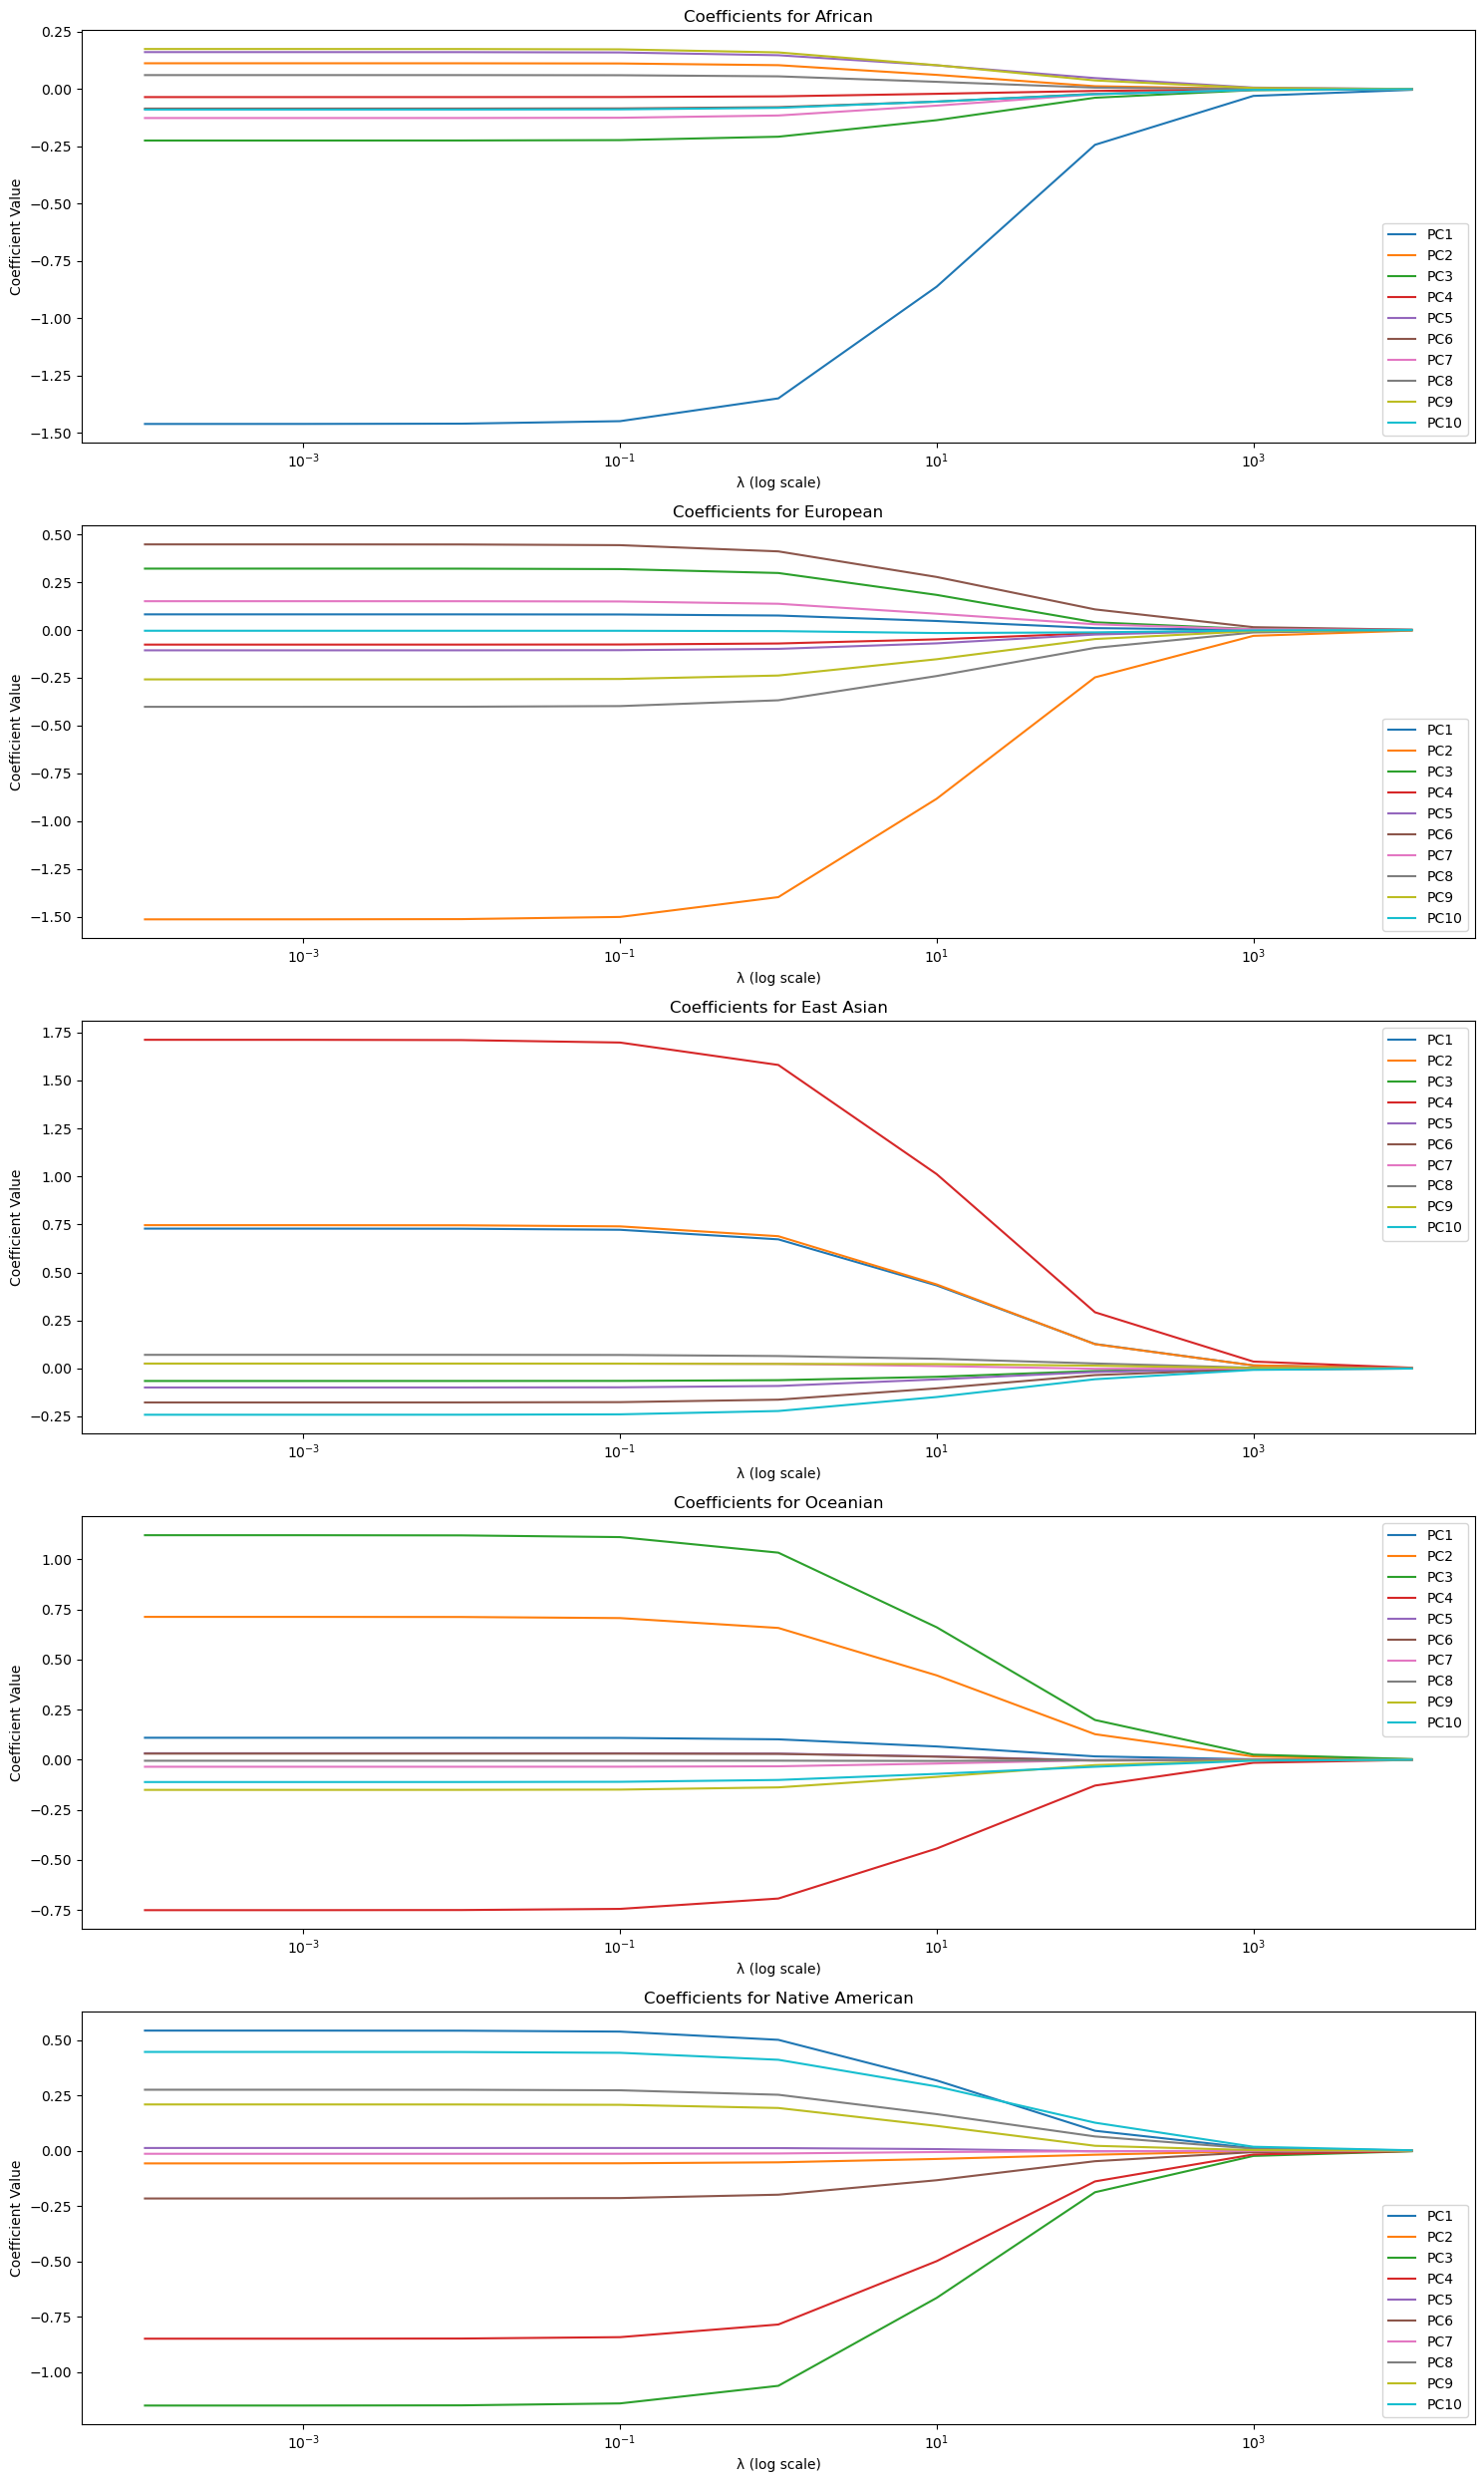

In [61]:
# Generate plots for Deliverable 1
plt.figure(figsize=(15, 25))
for k in range(num_classes):
    plt.subplot(5, 1, k+1)
    for j in range(num_features):
        coef_values = [beta[j+1, k] for beta in all_betas]
        plt.semilogx(lambda_params, coef_values, label=f'PC{j+1}')
    plt.title(f'Coefficients for {ancestry_types[k]}')
    plt.xlabel('λ (log scale)')
    plt.ylabel('Coefficient Value')
    plt.legend()
plt.tight_layout()
plt.savefig('ancestry_coefficients.png')



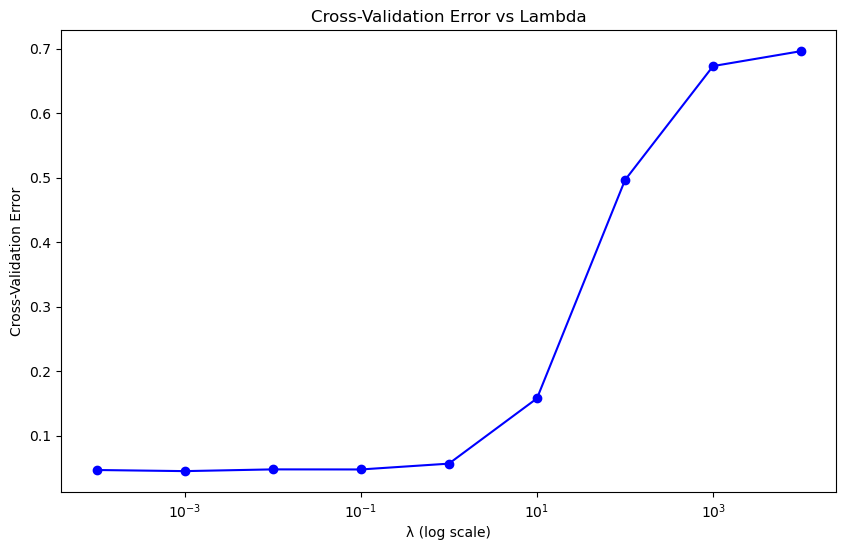

In [63]:
# Plot for Deliverable 2
plt.figure(figsize=(10, 6))
plt.semilogx(lambda_params, cv_errors, 'bo-')
plt.xlabel('λ (log scale)')
plt.ylabel('Cross-Validation Error')
plt.title('Cross-Validation Error vs Lambda')
plt.savefig('cv_error.png')



In [69]:
## Deliverable 3 (Optimal lambda value):
print(f"Best lambda value: {best_lambda}")

Best lambda value: 0.001


In [65]:
# Process test data
test_data = np.loadtxt(r"C:\Users\victo\OneDrive\Documentos\DATA SCIENCE AND ANALYTICS\FULL 2024\Computational Foundations AI\TestData_N111_p10.csv", delimiter=',', skiprows=1, dtype=str)
X_test = test_data[:, :num_features].astype(float)
test_ancestry = test_data[:, -1]

# Standardize test data using training parameters
X_test_std = (X_test - np.mean(X, axis=0)) / np.std(X, axis=0)
X_test_std = np.column_stack([np.ones(X_test_std.shape[0]), X_test_std])

# Train final model with best lambda
final_beta = train_model(X_std, y_encoded, best_lambda)

# Get predictions for test data
test_probs = np.exp(X_test_std @ final_beta)
test_probs = test_probs / np.sum(test_probs, axis=1, keepdims=True)
predicted_classes = np.argmax(test_probs, axis=1)

# Analyze different ancestry groups
unknown_mask = test_ancestry == 'Unknown'
mexican_mask = test_ancestry == 'Mexican'
african_am_mask = test_ancestry == 'AfricanAmerican'

# Print results
print("\nResults for Unknown samples:")
for i, (probs, is_unknown) in enumerate(zip(test_probs, unknown_mask)):
    if is_unknown:
        print(f"\nUnknown sample {i+1} probabilities:")
        for j, ancestry in enumerate(ancestry_types):
            print(f"{ancestry}: {probs[j]:.3f}")




Results for Unknown samples:

Unknown sample 1 probabilities:
African: 0.008
European: 0.006
East Asian: 0.005
Oceanian: 0.977
Native American: 0.005

Unknown sample 2 probabilities:
African: 0.002
European: 0.009
East Asian: 0.003
Oceanian: 0.003
Native American: 0.983

Unknown sample 3 probabilities:
African: 0.011
European: 0.933
East Asian: 0.037
Oceanian: 0.011
Native American: 0.007

Unknown sample 4 probabilities:
African: 0.931
European: 0.009
East Asian: 0.006
Oceanian: 0.045
Native American: 0.009

Unknown sample 5 probabilities:
African: 0.003
European: 0.001
East Asian: 0.990
Oceanian: 0.002
Native American: 0.004


In [71]:
## Deliverable 4 (Predictions for test samples):
test_probs = np.loadtxt('test_probabilities.csv', delimiter=',')
predicted_classes = np.loadtxt('predicted_classes.csv', delimiter=',')

# Display probabilities for each sample
for i in range(len(test_probs)):
    print(f"\nSample {i+1}:")
    for j, prob in enumerate(test_probs[i]):
        print(f"{ancestry_types[j]}: {prob:.3f}")


Sample 1:
African: 0.008
European: 0.006
East Asian: 0.005
Oceanian: 0.977
Native American: 0.005

Sample 2:
African: 0.002
European: 0.009
East Asian: 0.003
Oceanian: 0.003
Native American: 0.983

Sample 3:
African: 0.011
European: 0.933
East Asian: 0.037
Oceanian: 0.011
Native American: 0.007

Sample 4:
African: 0.931
European: 0.009
East Asian: 0.006
Oceanian: 0.045
Native American: 0.009

Sample 5:
African: 0.003
European: 0.001
East Asian: 0.990
Oceanian: 0.002
Native American: 0.004

Sample 6:
African: 0.015
European: 0.079
East Asian: 0.004
Oceanian: 0.005
Native American: 0.897

Sample 7:
African: 0.029
European: 0.207
East Asian: 0.011
Oceanian: 0.026
Native American: 0.727

Sample 8:
African: 0.025
European: 0.101
East Asian: 0.021
Oceanian: 0.012
Native American: 0.841

Sample 9:
African: 0.060
European: 0.256
East Asian: 0.032
Oceanian: 0.022
Native American: 0.629

Sample 10:
African: 0.058
European: 0.339
East Asian: 0.033
Oceanian: 0.017
Native American: 0.553

Sample 1

In [73]:
## Deliverable 5 (Analysis of Mexican and African American samples):

# For Mexican samples  
print("\nAverage ancestry proportions for Mexican samples:")
mexican_probs = test_probs[mexican_mask]
for i, ancestry in enumerate(ancestry_types):
    print(f"{ancestry}: {mexican_probs[:, i].mean():.3f}")

# For African American samples
print("\nAverage ancestry proportions for African American samples:")
african_am_probs = test_probs[african_am_mask]
for i, ancestry in enumerate(ancestry_types):
    print(f"{ancestry}: {african_am_probs[:, i].mean():.3f}")

# Save results
np.savetxt('test_probabilities.csv', test_probs, delimiter=',')
np.savetxt('predicted_classes.csv', predicted_classes, delimiter=',')


Average ancestry proportions for Mexican samples:
African: 0.049
European: 0.405
East Asian: 0.062
Oceanian: 0.038
Native American: 0.446

Average ancestry proportions for African American samples:
African: 0.759
European: 0.132
East Asian: 0.040
Oceanian: 0.029
Native American: 0.040
